# Day3: 머신러닝 이해와 실습

## 학습 내용
1. K-최근접이웃분류
2. 표준화가 K-최근접이웃분류 성능에 미치는 영향

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image

In [3]:
# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (5,5)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

## 1. 도미자료와 방어자료 불러오기

In [ ]:
# Image(url = "https://www.ikonet.com/en/visualdictionary/images/us/bony-fishes-271500.jpg",
#       width = 600, height = 400)

In [ ]:
# 도미 자료 (Bream Data) - 길이와 무게
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 빙어 자료 (Smelt Data) - 길이와 무게
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]


# list 길이
# 각 리스트의 길이를 출력합니다. (도미 35개, 방어 14개)
print(type(bream_length))
print("length of bream = ", len(bream_length), "\nlength of smelt = ",len(smelt_length))

# 각 변수별 평균값을 계산하고 소수점 셋째 자리에서 반올림하여 출력합니다.
print("mean of 도미길이 = ", round(np.mean(bream_length), 2))
print("mean of 방어길이 = ", round(np.mean(smelt_length), 2))

print("mean of 도미무게 = ", round(np.mean(bream_weight), 2))
print("mean of 방어무게 = ", round(np.mean(smelt_weight), 2))

<class 'list'>
length of bream =  35 
length of smelt =  14
mean of 도미길이 =  33.11
mean of 방어길이 =  11.92
mean of 도미무게 =  617.83
mean of 방어무게 =  11.18


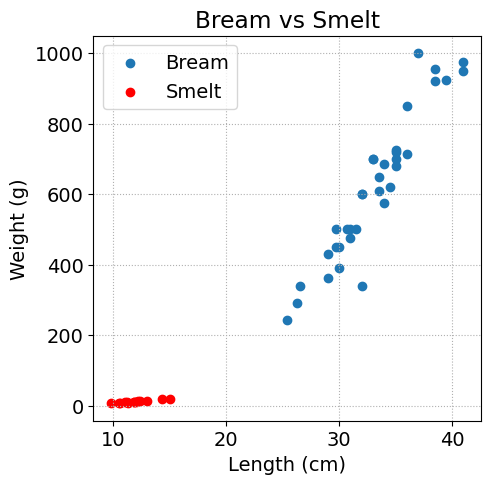

In [ ]:
# 도미(파란색)와 빙어(빨간색) 데이터를 산점도로 시각화합니다.

plt.scatter(bream_length, bream_weight, label = "Bream")
plt.scatter(smelt_length, smelt_weight, c = "r", label = "Smelt")
plt.xlabel('Length (cm)')
plt.ylabel('Weight (g)')
plt.title("Bream vs Smelt")
plt.legend()
plt.show()


## 2. list 자료를 sklearn 입력 형식에 맞게 수정

In [ ]:
# ----------------- 데이터 통합 및 타겟 설정 -----------------
# 도미와 빙어의 길이/무게 리스트를 하나로 합칩니다. (도미 자료가 먼저, 빙어 자료가 나중)
length = bream_length + smelt_length
weight = bream_weight + smelt_weight

# 통합된 길이와 무게 리스트를 출력하고 길이를 확인합니다.
print("length = \n", length)
print("length length = ", len(length))

print("\nweight = \n", weight)
print("weight length = ", len(weight))


length = 
 [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
length length =  49

weight = 
 [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]
weight length =  49


In [ ]:
# NumPy를 사용하여 길이(length)와 무게(weight) 리스트를 열 방향(column)으로 붙여 2차원 배열을 생성합니다.
# fish_data는 독립 변수(특성) 데이터셋이 됩니다.
fish_data = np.column_stack((length, weight))

# fish_data 배열의 크기(49행, 2열)를 출력합니다.
print("배열크기 fish_data = ", np.shape(fish_data))

print(fish_data[:10,])

배열크기 fish_data =  (49, 2)
[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]
 [ 29.7 450. ]
 [ 29.7 500. ]
 [ 30.  390. ]
 [ 30.  450. ]
 [ 30.7 500. ]]


In [ ]:
# 타겟(레이블) 설정: 도미는 1 (35개), 빙어는 0 (14개)으로 인덱스 배열을 생성합니다.
one_index = np.ones(35)
zero_index = np.zeros(14)

print("one_index = \n", one_index)
print("zero_index = \n", zero_index)

# 도미 타겟(1)과 빙어 타겟(0)을 합쳐 최종 타겟 배열(fish_target)을 생성합니다.
fish_target = np.append(one_index, zero_index)

print("\nfish_target = \n", fish_target)

one_index = 
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
zero_index = 
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

fish_target = 
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


## 3. 훈련세트와 테스트 세트 나누기

In [ ]:
# ----------------- 훈련/테스트 데이터 분할 -----------------
# fish_data와 fish_target을 훈련 세트와 테스트 세트로 나눕니다.
# train_size = 0.7: 훈련 세트 70% (34개), 테스트 세트 30% (15개)
# stratify=fish_target: 타겟 클래스(0과 1)의 비율을 유지하며 분할합니다. (편향 방지)
# random_state=42: 무작위 추출을 위한 시드값 설정 (결과 재현 가능하게 함)

from  sklearn.model_selection import train_test_split

# default test_size = 0.25
train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, train_size = 0.7, stratify=fish_target, random_state=42)

print('훈련자료 배열크기 = {0}, 테스트자료 배열크기 = {1}'.format(train_input.shape, test_input.shape))

훈련자료 배열크기 = (34, 2), 테스트자료 배열크기 = (15, 2)


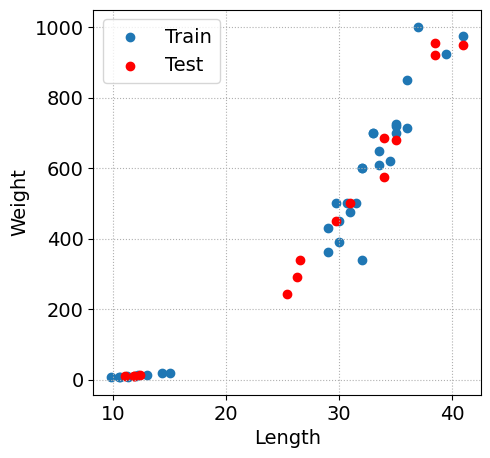

In [ ]:
# 훈련 세트(파란색)와 테스트 세트(빨간색)를 산점도로 시각화하여 분리된 상태를 확인합니다

plt.scatter(train_input[:, 0], train_input[:, 1], label = "Train")
plt.scatter(test_input[:, 0], test_input[:, 1], c = "r", label = "Test")
plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.show()

## 4. 표준화 (Standardization)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
## knn 학습 parameter
#### n_neighbors : int, default=5
#### weights : {'uniform', 'distance'} or callable, default='uniform'
#### algorithm : {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'
#### leaf_size : int, default=30
#### p : int, default = 2
#### metric : str or callable, default='minkowski'

# KNN 분류기 객체를 생성합니다.
# n_neighbors=5: 가장 가까운 5개의 이웃 사용
# p=2: 유클리디안 거리(Euclidean distance)를 사용 (L2 norm)
kn = KNeighborsClassifier(n_neighbors=5, p = 2)
# 훈련 세트를 사용하여 모델을 학습시킵니다
kn.fit(train_input, train_target)
# 테스트 세트를 사용하여 모델의 정확도(score)를 평가합니다.
kn.score(test_input, test_target)

1.0

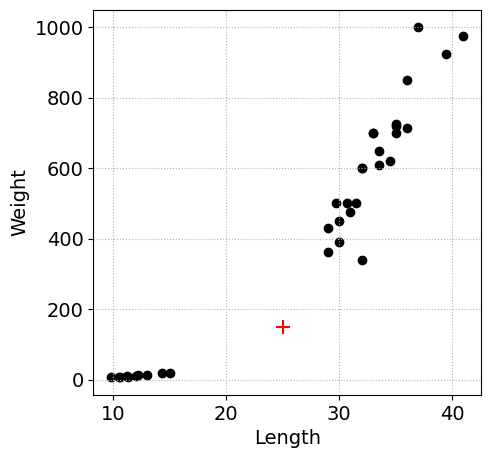

In [ ]:
# 훈련 세트 데이터를 검정색 점(k)으로 시각화합니다.
plt.scatter(train_input[:,0], train_input[:,1], c = "k")
# 새로운 데이터 포인트 [길이=25, 무게=150]를 빨간색 십자(+) 마커로 표시합니다.
plt.scatter(25, 150, marker = "+", s = 100, c = "r")
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

### 표준화 전 자료를 이용한 KNN

In [ ]:
# 새로운 포인트 [25, 150]에 가장 가까운 K=5개의 훈련 데이터를 찾습니다.
distance, index = kn.kneighbors([[25, 150]])
# 5개 이웃과의 거리를 출력합니다.
print("distance = \n", distance)
# 5개 이웃의 훈련 데이터 인덱스를 출력합니다. (주로 빙어 인덱스가 나올 것임)
print("index = \n", index)

distance = 
 [[130.48375378 130.73859415 138.32150953 138.39320793 140.80142045]]
index = 
 [[29 16 26  0 11]]


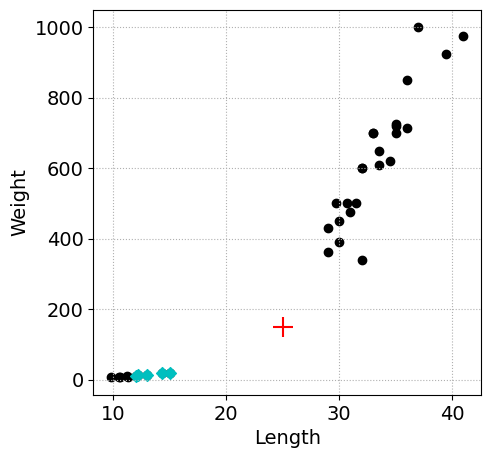

In [54]:
# 새로운 포인트와 그 이웃들을 시각화합니다.
plt.scatter(train_input[:,0], train_input[:,1], c = "k")
plt.scatter(25, 150, marker ="+", c = "r", s = 200)
# 이웃으로 선택된 5개 포인트를 청록색 마름모(D)로 표시합니다.
plt.scatter(train_input[index, 0], train_input[index, 1],
            marker = "D", c = "c")
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

### 이웃한 데이터 포인트찾기

In [45]:
print('훈련자료의 이웃자료 = \n{0}, \n훈련자료의 그룹 = {1}'.format(train_input[index], train_target[index]))
print('\n훈련자료와의 거리는 = {}'.format(distance))


훈련자료의 이웃자료 = 
[[[15.  19.9]
  [14.3 19.7]
  [13.  12.2]
  [12.2 12.2]
  [12.   9.8]]], 
훈련자료의 그룹 = [[0. 0. 0. 0. 0.]]

훈련자료와의 거리는 = [[130.48375378 130.73859415 138.32150953 138.39320793 140.80142045]]


### 자료의 표준화 (Feature scaling)

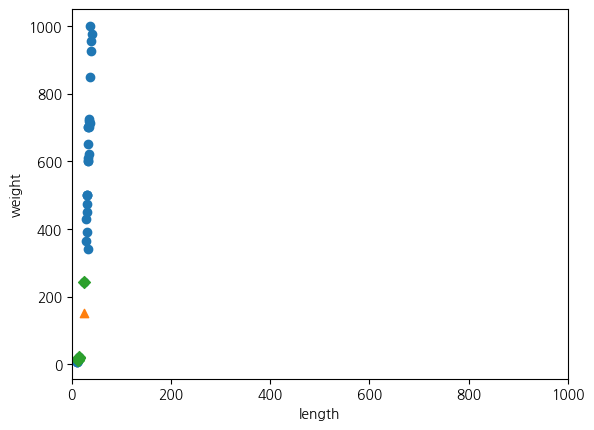

In [ ]:
# 축의 범위를 변경하여 시각화합니다.
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[index,0], train_input[index,1], marker='D')
plt.xlim((0, 1000))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

### 표준화 된 후 자료를 이용한 KNN

In [ ]:
# 훈련 세트의 데이터를 표준화(Z-score 스케일링)합니다. (train_scaled)
# 공식: Z = (X - mean) / std
mean = np.mean(train_input, axis = 0)
std = np.std(train_input, axis = 0)
print('평균은 ={0}, 표준편차 = {1}'.format(mean, std))

train_scaled = (train_input - mean)/std

평균은 =[ 27.02352941 445.60294118], 표준편차 = [ 10.0816099  319.21122132]


z-score 점수는 = [-0.20071491 -0.61276963]


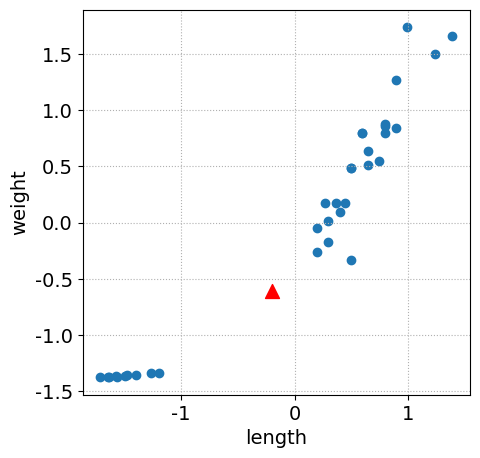

In [ ]:
# 예측할 새로운 포인트 [25, 150]도 훈련 세트의 평균과 표준편차를 이용해 스케일링합니다.
new = ([25, 250] - mean)/std
print('z-score 점수는 =', new)

# 스케일링된 훈련 데이터와 새로운 포인트의 위치를 시각화합니다.
# 데이터가 중앙(0 근처)에 모여 있고, 축 범위가 비슷해진 것을 확인합니다.
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^', s  = 100, c = "r")
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [55]:
# ----------------- KNN 모델 재학습 및 평가 (스케일링 후) -----------------
# 스케일링된 훈련 세트로 KNN 모델을 다시 학습시킵니다.
kn.fit(train_scaled, train_target)
# 테스트 세트도 훈련 세트의 평균/표준편차를 이용해 스케일링합니다.
test_scaled = (test_input - mean) / std

# 스케일링된 테스트 세트로 모델의 정확도를 평가합니다. (정확도가 향상되었을 것)
kn.score(test_scaled, test_target)
print('Accuracy of test set= ', kn.score(test_scaled, test_target))
print(kn.predict([new]))
# print(kn.predict_proba([new]))

Accuracy of test set=  1.0
[1.]


In [ ]:
# 스케일링된 새로운 포인트에 가장 가까운 K=5개의 이웃을 다시 찾습니다.
distances, indexes = kn.kneighbors([new])

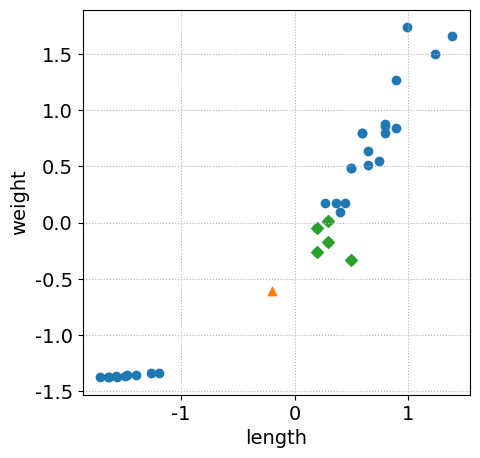

In [56]:
# 스케일링된 훈련 데이터와 새로운 포인트, 그리고 이웃들을 시각화합니다.
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
# 이웃으로 선택된 5개 포인트를 마름모(D)로 표시합니다. (이번에는 도미 그룹이 이웃으로 선택될 것)
plt.scatter(train_scaled[indexes,0], train_scaled[indexes,1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()